In [1]:
import pandas as pd
import numpy as np
from skbio import TreeNode
from skbio.diversity import alpha_diversity
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
from skbio.stats.composition import multiplicative_replacement
import matplotlib.pyplot as plt
import seaborn as sns

from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
compartment = 'oral'
balance = False
mortality_rate = 'Mortality90Day'
dont_use_top_50_features = False

/Users/binay/researchenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Loading filtered data with relative abundance and metadata

In [2]:
filtered_data_combined = pd.read_csv('filtered_data/filtered_data_combined.csv')
filtered_metadata = pd.read_csv('filtered_data/filtered_metadata.csv')
filtered_relative_abundance = pd.read_csv('filtered_data/filtered_relative_abundance.csv')
filtered_clr_abundance = pd.read_csv('filtered_data/filtered_clr_abundance.csv')
print(f"Size of taxa: {filtered_relative_abundance.shape}")
print(f"Size of metadata: {filtered_metadata.shape}")

Size of taxa: (1718, 225)
Size of metadata: (1718, 536)


/var/folders/n0/11zhyd692c73yhvg7cgntrth0000gq/T/ipykernel_12710/3803470334.py:1: DtypeWarning: Columns (6,23,275,277,280,282,284,287,290,291,292,295,296,297,299,300,364,396) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_data_combined = pd.read_csv('filtered_data/filtered_data_combined.csv')
/var/folders/n0/11zhyd692c73yhvg7cgntrth0000gq/T/ipykernel_12710/3803470334.py:2: DtypeWarning: Columns (6,23,275,277,280,282,284,287,290,291,292,295,296,297,299,300,364,396) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_metadata = pd.read_csv('filtered_data/filtered_metadata.csv')


In [3]:
filtered_relative_abundance

,Unnamed: 0,Methanobrevibacter,Actinobacteria_uncl,Actinomyces,F0332,Mobiluncus,Varibaculum,Alloscardovia,Bifidobacteriaceae_uncl,Bifidobacterium,...,Aggregatibacter,Haemophilus,Pasteurellaceae_uncl,Acinetobacter,Pseudomonadaceae_uncl,Pseudomonas,Stenotrophomonas,Treponema,Fretibacterium,Akkermansia
0,0102.4156.10.T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.931034,0.000000,0.0,0.0,0.0
1,0102.4336.1.ETA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,0102.3987.1.T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000100,0.000000,0.0,0.0,0.0
3,0102.3699.7.T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,0102.4636.5.UNDEP.ETA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.999600,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1713,0111.SF001.V1.BALCon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.124186,0.000000,0.258638,0.000000,0.0,0.0,0.0
1714,0111.SF002.V1.BALCon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.038830,0.000306,0.278435,0.000000,0.0,0.0,0.0
1715,0111.SF003.V1.BALCon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.058723,0.000000,0.175865,0.019171,0.0,0.0,0.0
1716,0111.SF004.V1.BALCon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.055191,0.000000,0.236072,0.028116,0.0,0.0,0.0


In [4]:
# Compartment type data selection( oral, lung, gut ) 
filtered_metadata_by_compartment = filtered_metadata[filtered_metadata['compartment'] == compartment]

In [5]:
# Drop the samples with no mortality90day feature
filtered_metadata_by_compartment = filtered_metadata_by_compartment.dropna(subset=['Mortality90Day'])
# cleared_relative_abundance = filtered_relative_abundance.dropna(subset=['Mortality90Day'])

## Feature Selection

In [7]:
print(cleared_metadata['Mortality90Day'].isna().sum())
target_df = cleared_metadata['Mortality90Day']

target_counts = target_df.value_counts()
print(target_counts)

0
Mortality90Day
0.0    418
1.0    158
Name: count, dtype: int64


In [8]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Load the data (assuming df contains the relative abundance data)
X = df_to_autoencoder  # Remove non-feature column
y = target_df  # Target variable (Mortality90Day)

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create a DataFrame to store taxa and their importance
taxa_importance = pd.DataFrame({
    'Taxa': X.columns,
    'Mutual_Information': mi_scores
})

# Sort taxa by importance (descending order)
taxa_importance = taxa_importance.sort_values(by='Mutual_Information', ascending=False)

# Reset index for better readability
taxa_importance = taxa_importance.reset_index(drop=True)

# Display the ranked taxa DataFrame
print(taxa_importance)


                        Taxa  Mutual_Information
0             Negativicoccus            0.050585
1                Eggerthella            0.045462
2       Oscillospirales_uncl            0.040660
3                 Finegoldia            0.038372
4             Capnocytophaga            0.038232
..                       ...                 ...
218               Monoglobus            0.000000
219  Lachnospiraceae_Uncltrd            0.000000
220               Tuzzerella            0.000000
221           Shuttleworthia            0.000000
222      Actinobacteria_uncl            0.000000

[223 rows x 2 columns]


## Least Important taxa removed

In [11]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

def remove_least_important_features(df, target_df, num_features_to_remove=50):

    # Get the least important features (the first `num_features_to_remove` taxa)
    least_important_taxa = taxa_importance['Taxa'].head(num_features_to_remove).tolist()

    # Remove these features from the original dataframe
    filtered_df = df_to_autoencoder.drop(columns=least_important_taxa, errors='ignore')

    return filtered_df

# Example usage:
filtered_df = remove_least_important_features(df_to_autoencoder, target_df)  # Removes 50 least important features by default
filtered_df_30 = remove_least_important_features(df_to_autoencoder, target_df, num_features_to_remove=30)  # Removes 30 least important features


In [12]:
import pandas as pd
from sklearn.utils import resample

target_variable = 'Mortality90Day'

# Drop rows with NaN values in the target variable

# Separate majority and minority classes
df_majority = cleared_metadata[cleared_metadata[target_variable] == 0.0]  # Survivors (majority)
df_minority = cleared_metadata[cleared_metadata[target_variable] == 1.0]  # Deceased (minority)

# Undersample majority class to match the minority class size
df_majority_downsampled = resample(df_majority,
                                   replace=False,  # Sample without replacement
                                   n_samples=len(df_minority),  # Match minority class size
                                   random_state=42)  # Ensure reproducibility

# Combine downsampled majority class with minority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class distribution
print("Original class distribution:")
print(cleared_metadata[target_variable].value_counts())

print("\nBalanced class distribution after undersampling:")
print(df_balanced[target_variable].value_counts())


Original class distribution:
Mortality90Day
0.0    418
1.0    158
Name: count, dtype: int64

Balanced class distribution after undersampling:
Mortality90Day
1.0    158
0.0    158
Name: count, dtype: int64


In [29]:
df_balanced.shape
target_df = df_balanced[mortality_rate]

In [30]:
# Get the relative data for relative abundance table
df_to_autoencoder = filtered_relative_abundance[filtered_relative_abundance['Unnamed: 0'].isin(df_balanced['Unnamed: 0'])].iloc[:,2:]
df_to_autoencoder.shape, df_balanced.shape, target_df.shape

((316, 223), (316, 536), (316,))

## Autoencoder Model with only relative abundance

## 1. Import Libraries and Define Autoencoder Model

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        initial_dim = 192 if input_dim < 270 else 256
        print(initial_dim, 'initial_ dim')
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, initial_dim),
            nn.ReLU(),
            nn.Linear(initial_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, encoding_dim),
            # nn.ReLU(),
            # nn.Linear(16, encoding_dim)  # Latent space
        )
        self.decoder = nn.Sequential(
            # nn.Linear(encoding_dim, 16),
            # nn.ReLU(),
            nn.Linear(encoding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, initial_dim),
            nn.ReLU(),
            nn.Linear(initial_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

## 2. Define Classifier Model

In [32]:
class Classifier(nn.Module):
    def __init__(self, encoding_dim):
        super(Classifier, self).__init__()
        self.fc1 = nn.Linear(encoding_dim, encoding_dim*2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(encoding_dim*2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

## 3. Prepare Data


In [33]:
# Prepare your data
data_tensor = torch.tensor(df_to_autoencoder.values, dtype=torch.float32)
target_tensor = torch.tensor(target_df.values, dtype=torch.float32).unsqueeze(1)

train_size = int(0.7 * len(data_tensor))
val_size = int(0.15 * len(data_tensor))
test_size = len(data_tensor) - train_size - val_size

train_data, val_data, test_data = torch.utils.data.random_split(
    list(zip(data_tensor, target_tensor)), [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## 4. Initialize Autoencoder and Train

In [34]:
# Model parameters
input_dim = data_tensor.shape[1]
encoding_dim = 16

# Initialize the Autoencoder
autoencoder = Autoencoder(input_dim, encoding_dim)
optimizer_ae = optim.Adam(autoencoder.parameters(), lr=0.001)
criterion_ae = nn.MSELoss()

# Store losses for plotting
autoencoder_losses = []

# Train the Autoencoder
num_epochs_ae = 100
for epoch in range(num_epochs_ae):
    autoencoder.train()
    total_loss = 0
    for data, _ in train_loader:
        optimizer_ae.zero_grad()
        _, decoded = autoencoder(data)
        loss = criterion_ae(decoded, data)
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()
    autoencoder_losses.append(total_loss / len(train_loader))
    # print(f"Epoch {epoch + 1}/{num_epochs_ae}, Autoencoder Loss: {total_loss / len(train_loader)}")

192 initial_ dim


## 5. Extract Latent Representations and Prepare Classifier Data

In [35]:
# Extract latent representations for the training set
autoencoder.eval()
latent_representations = []
mortality_labels = []

with torch.no_grad():
    for data, labels in train_loader:
        encoded = autoencoder.encoder(data)
        latent_representations.append(encoded)
        mortality_labels.append(labels)

latent_representations = torch.cat(latent_representations).cpu().numpy()
mortality_labels = torch.cat(mortality_labels).cpu().numpy()

# Convert latent representations and labels to tensors for classifier training
latent_train_tensor = torch.tensor(latent_representations, dtype=torch.float32)
mortality_train_tensor = torch.tensor(mortality_labels, dtype=torch.float32)

## 6. Initialize Classifier and Train

In [36]:
classifier = Classifier(encoding_dim)
optimizer_clf = optim.Adam(classifier.parameters(), lr=0.001)
criterion_clf = nn.BCELoss()

classifier_losses = []

num_epochs_clf = 100
for epoch in range(num_epochs_clf):
    classifier.train()
    optimizer_clf.zero_grad()
    outputs = classifier(latent_train_tensor)
    loss = criterion_clf(outputs, mortality_train_tensor)
    loss.backward()
    optimizer_clf.step()
    classifier_losses.append(loss.item())
    # print(f"Epoch {epoch + 1}/{num_epochs_clf}, Classifier Loss: {loss.item()}")

## 7. Plot The Losses

In [37]:
# Reassign the losses

if compartment == 'lung': 
    lung_autoencoder_losses = autoencoder_losses
    lung_classifier_losses = classifier_losses
elif compartment == 'oral':
    oral_autoencoder_losses = autoencoder_losses
    oral_classifier_losses = classifier_losses
else:
    gut_autoencoder_losses = autoencoder_losses
    gut_classifier_losses = classifier_losses

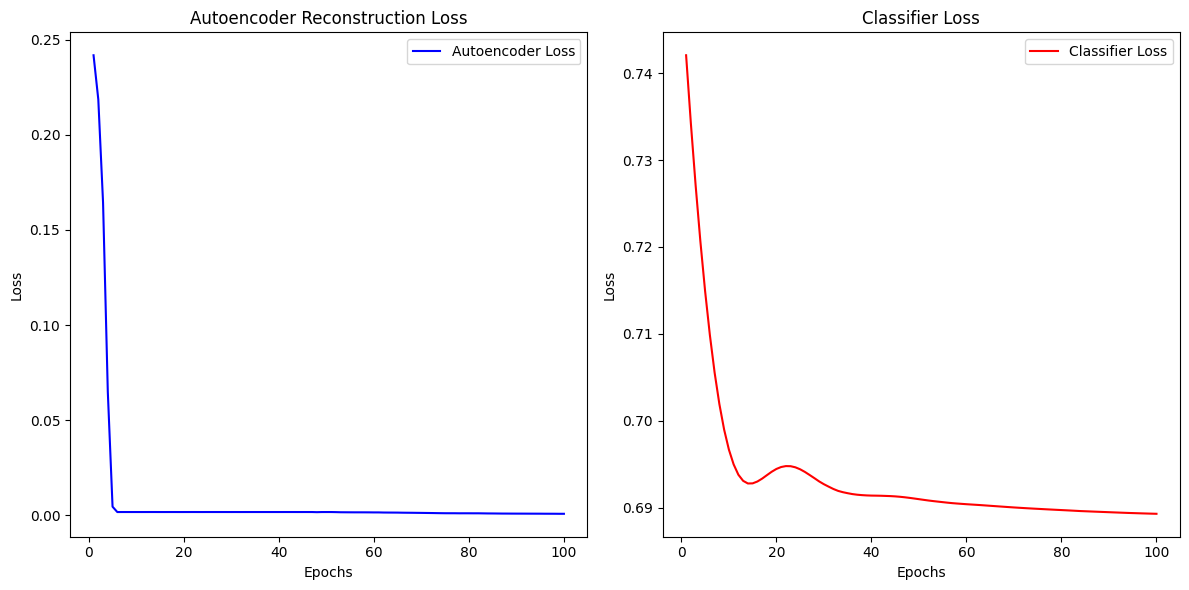

In [38]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs_ae + 1), autoencoder_losses, label="Autoencoder Loss", color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Autoencoder Reconstruction Loss")
plt.legend()

# Classifier Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs_clf + 1), classifier_losses, label="Classifier Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Classifier Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluate Model (Validation and Test)

Validation Accuracy: 0.5319148936170213
Test Accuracy: 0.4583333333333333
Classification Report:
               precision    recall  f1-score   support

         0.0       0.48      0.52      0.50        25
         1.0       0.43      0.39      0.41        23

    accuracy                           0.46        48
   macro avg       0.46      0.46      0.45        48
weighted avg       0.46      0.46      0.46        48



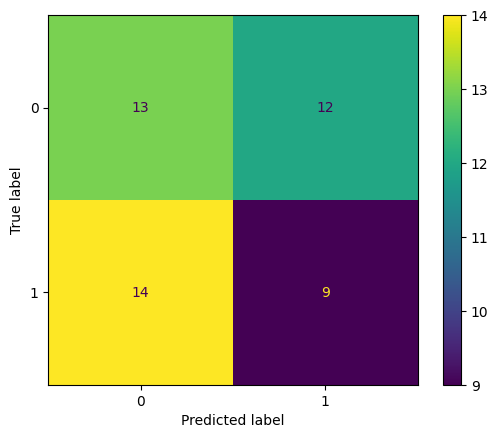

In [39]:
# Validation and evaluation on test set
classifier.eval()
def evaluate_model(loader):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data, labels in loader:
            encoded = autoencoder.encoder(data)
            outputs = classifier(encoded)
            preds = (outputs > 0.5).float()
            all_preds.append(preds)
            all_labels.append(labels)
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    return all_labels, all_preds

val_labels, val_preds = evaluate_model(val_loader)
val_accuracy = accuracy_score(val_labels, val_preds)
print("Validation Accuracy:", val_accuracy)

# Test Accuracy and Classification Report
test_labels, test_preds = evaluate_model(test_loader)
test_accuracy = accuracy_score(test_labels, test_preds)
print("Test Accuracy:", test_accuracy)
print("Classification Report:\n", classification_report(test_labels, test_preds))

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [40]:
# print("Compartment And Balanced and Mortality Rate:", compartment, balance, mortality_rate)
# print(30*'--')

# print("Final Data:", df_to_autoencoder.shape)

# print('Shapes: ')
# print('Original Data Shape:', merged_data.shape)
# print(30*'--')
# print('Processed Data Shape:', final_features_vif.shape)
# print(30*'--')
# print('Unbalanced Data')
# print(df_normalized['Mortality90Day'].value_counts())
# print(30*'--')
# print('Balanced Data')
# print(df_balanced['Mortality90Day'].value_counts())

## Alpha and Beta Diversity

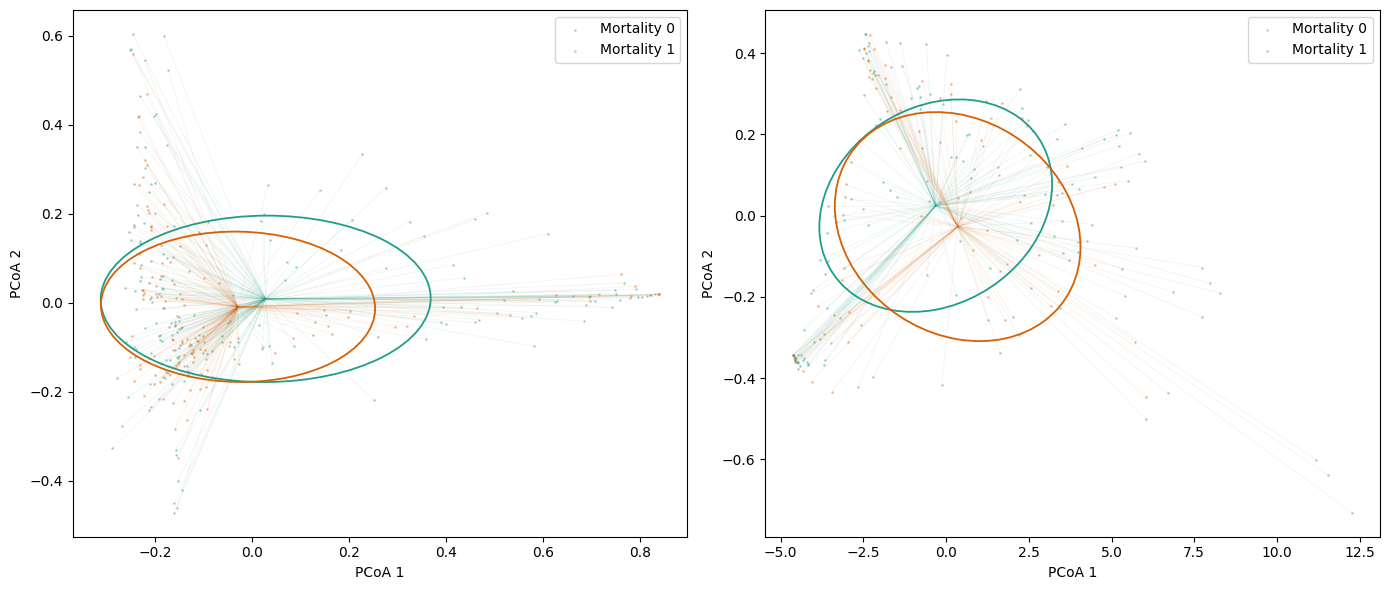

In [42]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from matplotlib.patches import Ellipse

cluster_colors = {'Mortality 0': '#1f9e89', 'Mortality 1': '#d95f02'}

balanced_key = 'balanced' if balance else 'un_balanced'

all_data_features = df_to_autoencoder.values
all_data_labels = target_df.values

pca = PCA(n_components=2)
initial_pca = pca.fit_transform(all_data_features)

initial_df = pd.DataFrame({'PCoA1': initial_pca[:, 0], 'PCoA2': initial_pca[:, 1], f"{mortality_rate}": all_data_labels})
initial_df['cluster'] = initial_df[mortality_rate].apply(lambda x: 'Mortality 0' if x == 0 else 'Mortality 1')

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for cluster, group in initial_df.groupby('cluster'):
    plt.scatter(group['PCoA1'], group['PCoA2'], color=cluster_colors[cluster], s=1, alpha=0.3, label=cluster)  # Smaller point size
# plt.colorbar(sc1, label=mortality_rate)
plt.xlabel("PCoA 1")
plt.ylabel("PCoA 2")
plt.legend()
# plt.title(f"PCoA Plot of Entire Initial Dataset (Colored by {mortality_rate})")

for cluster, group in initial_df.groupby('cluster'):
    cov = np.cov(group[['PCoA1', 'PCoA2']].values, rowvar=False)
    mean = group[['PCoA1', 'PCoA2']].mean().values
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    theta = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues)
    ellip = Ellipse(xy=mean, width=width, height=height, angle=theta, edgecolor=cluster_colors[cluster], facecolor='none', lw=1.3)
    plt.gca().add_patch(ellip)
    # plt.text(mean[0], mean[1], cluster, color=cluster_colors[cluster], ha='center')
    for idx, row in group.iterrows():
        plt.plot([row['PCoA1'], mean[0]], [row['PCoA2'], mean[1]], color=cluster_colors[cluster], alpha=0.1, lw=0.5)

autoencoder.eval()
latent_representations = []
mortality_labels = []

with torch.no_grad():
    for data, labels in train_loader:
        encoded = autoencoder.encoder(data)
        latent_representations.append(encoded)
        mortality_labels.append(labels)

latent_representations = torch.cat(latent_representations).cpu().numpy()
mortality_labels = torch.cat(mortality_labels).cpu().numpy().flatten()

latent_pca = pca.fit_transform(latent_representations)

latent_df = pd.DataFrame({'PCoA1': latent_pca[:, 0], 'PCoA2': latent_pca[:, 1], mortality_rate: mortality_labels})
latent_df['cluster'] = latent_df[mortality_rate].apply(lambda x: 'Mortality 0' if x == 0 else 'Mortality 1')

plt.subplot(1, 2, 2)
for cluster, group in latent_df.groupby('cluster'):
    plt.scatter(group['PCoA1'], group['PCoA2'], color=cluster_colors[cluster], s=1, alpha=0.3, label=cluster)  # Smaller point size
# plt.colorbar(sc2, label=mortality_rate)
plt.xlabel("PCoA 1")
plt.ylabel("PCoA 2")
plt.legend()
# plt.title(f"PCoA Plot of Latent Space (Colored by {mortality_rate})")

# Draw ellipses and connecting lines for the latent space
for cluster, group in latent_df.groupby('cluster'):
    cov = np.cov(group[['PCoA1', 'PCoA2']].values, rowvar=False)
    mean = group[['PCoA1', 'PCoA2']].mean().values
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    theta = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues)
    ellip = Ellipse(xy=mean, width=width, height=height, angle=theta, edgecolor=cluster_colors[cluster], facecolor='none', lw=1.3)
    plt.gca().add_patch(ellip)
    # plt.text(mean[0], mean[1], cluster, color=cluster_colors[cluster], ha='center')
    for idx, row in group.iterrows():
        plt.plot([row['PCoA1'], mean[0]], [row['PCoA2'], mean[1]], color=cluster_colors[cluster], alpha=0.1, lw=0.5)

plt.tight_layout()
# if dont_use_top_50_features: 
#     plt.savefig(f"PCoA_Plots/without_important/{compartment}_{balanced_key}_pcoa_comparision.png", dpi=300, bbox_inches='tight')
# else: 
#     plt.savefig(f"PCoA_Plots/{compartment}_{balanced_key}_pcoa_comparision.png", dpi=300, bbox_inches='tight')
# plt.show()

In [43]:
import pandas as pd
import numpy as np
from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform

# Function to compute PERMANOVA p-value
def compute_permanova(df, group_column):
    """
    Computes PERMANOVA p-value for beta diversity analysis.

    Parameters:
    df (DataFrame): Data containing PCoA coordinates.
    group_column (str): Column name representing group labels.

    Returns:
    p-value of the PERMANOVA test.
    """
    # Compute distance matrix using Euclidean or Bray-Curtis distance
    distance_matrix = squareform(pdist(df[['PCoA1', 'PCoA2']], metric='euclidean'))  # Try 'braycurtis' if needed

    # Convert to DistanceMatrix format required for PERMANOVA
    dist_matrix = DistanceMatrix(distance_matrix, ids=df.index.astype(str))  # Ensure matching index
    
    # Ensure grouping labels match the DistanceMatrix index
    grouping = df[group_column].astype(str)  # Convert to string for consistency
    grouping.index = dist_matrix.ids  # Align indices

    # Run PERMANOVA test
    results = permanova(dist_matrix, grouping, permutations=999)
    
    return results

# Ensure indices are unique and match
initial_df = initial_df.reset_index(drop=True)
latent_df = latent_df.reset_index(drop=True)

# Compute PERMANOVA for Initial Dataset
print("PERMANOVA for Initial Dataset:")
permanova_initial = compute_permanova(initial_df, "cluster")
print(permanova_initial)

# Compute PERMANOVA for Latent Space
print("\nPERMANOVA for Latent Space:")
permanova_latent = compute_permanova(latent_df, "cluster")
print(permanova_latent)

PERMANOVA for Initial Dataset:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     316
number of groups                  2
test statistic             2.179043
p-value                       0.111
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA for Latent Space:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     221
number of groups                  2
test statistic             1.858341
p-value                       0.171
number of permutations          999
Name: PERMANOVA results, dtype: object


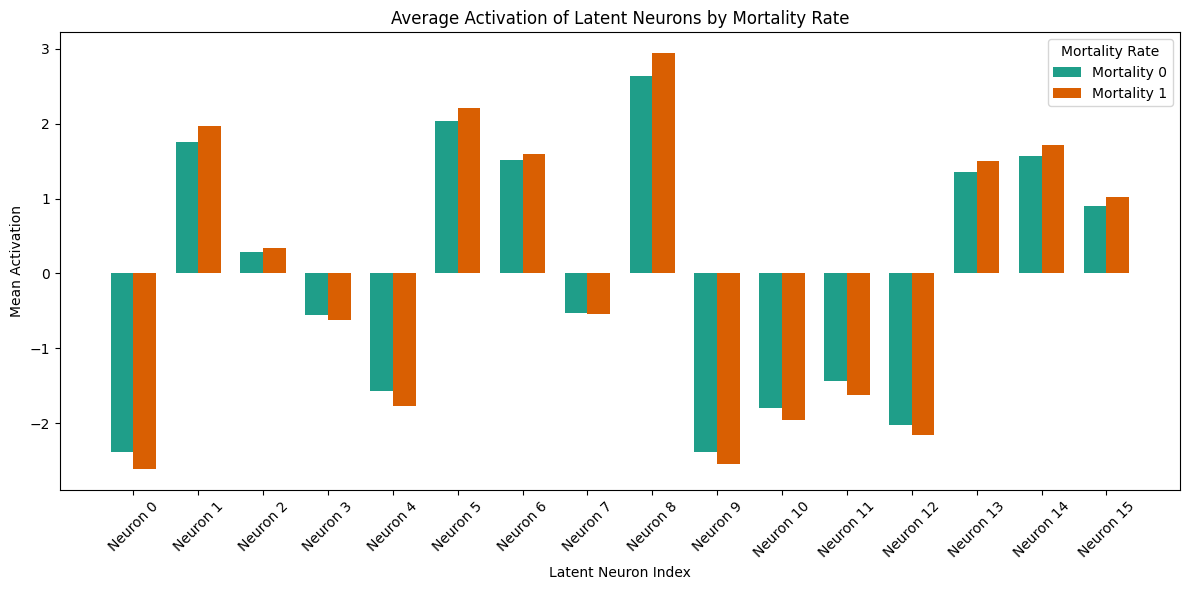

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Convert MortalityRate into binary groups
mortality_rate_0 = latent_representations[mortality_labels == 0]
mortality_rate_1 = latent_representations[mortality_labels == 1]

# Compute mean activations for each group
mean_activations_0 = np.mean(mortality_rate_0, axis=0)
mean_activations_1 = np.mean(mortality_rate_1, axis=0)

# Plot bar charts for both groups
bar_width = 0.35
indices = np.arange(len(mean_activations_0))

plt.figure(figsize=(12, 6))

# Bars for MortalityRate 0
plt.bar(indices - bar_width/2, mean_activations_0, width=bar_width, color='#1f9e89', label='Mortality 0')

# Bars for MortalityRate 1
plt.bar(indices + bar_width/2, mean_activations_1, width=bar_width, color='#d95f02', label='Mortality 1')

# Customization
plt.xlabel('Latent Neuron Index')
plt.ylabel('Mean Activation')
plt.title('Average Activation of Latent Neurons by Mortality Rate')
plt.xticks(indices, [f'Neuron {i}' for i in range(len(mean_activations_0))], rotation=45)
plt.legend(title='Mortality Rate')

# Save and display
plt.tight_layout()
# if not dont_use_top_50_features:
#     plt.savefig(f"Activation_Plots/BarPlots/{compartment}_{balanced_key}_mortality_barplots.png", format="png", bbox_inches="tight")
# plt.show()

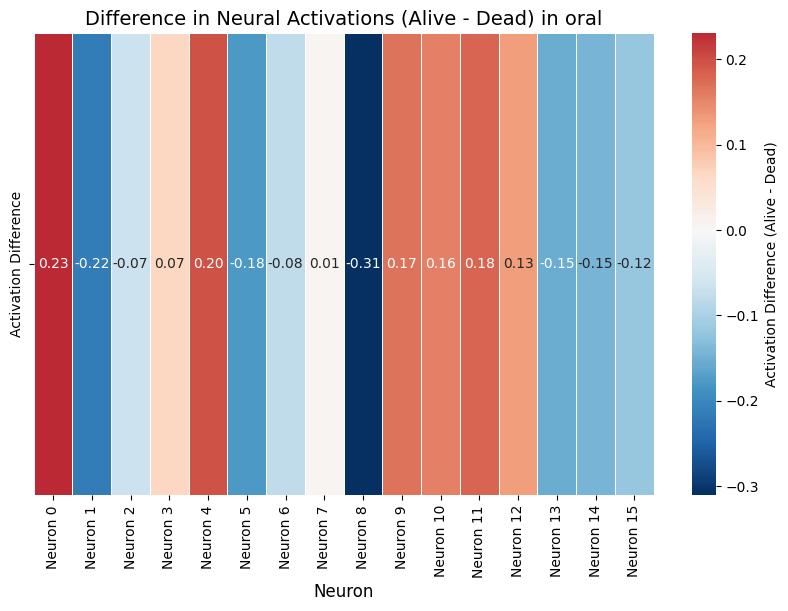

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert latent representations to a DataFrame for Seaborn
latent_df = pd.DataFrame(latent_representations, columns=[f"Neuron {i}" for i in range(latent_representations.shape[1])])

# Add MortalityRate as a new column
latent_df['MortalityRate'] = mortality_labels

# Step 1: Compute Mean Activations for Alive and Dead Groups
alive_mean = latent_df[latent_df['MortalityRate'] == 0].drop(columns=['MortalityRate']).mean()
dead_mean = latent_df[latent_df['MortalityRate'] == 1].drop(columns=['MortalityRate']).mean()

# Step 2: Compute the Difference (Alive - Dead)
activation_diff = alive_mean - dead_mean

# Step 3: Convert to DataFrame for Heatmap
activation_diff_df = pd.DataFrame(activation_diff, columns=["Activation Difference"])
activation_diff_df.index.name = "Neuron"

# Step 4: Create the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    activation_diff_df.T,  # Transpose for better visualization
    cmap="RdBu_r",  # Diverging colormap (red-blue)
    center=0,  # Ensure 0 is neutral
    annot=True,  # Show numerical values
    fmt=".2f",  # Two decimal places
    linewidths=0.5,  # Add gridlines
    cbar_kws={'label': 'Activation Difference (Alive - Dead)'}
)

# Step 5: Customize Labels and Titles
plt.title(f"Difference in Neural Activations (Alive - Dead) in {compartment}", fontsize=14)
plt.xlabel("Neuron", fontsize=12)
plt.ylabel("")

# Save or Show the Plot
# if dont_use_top_50_features:
#     plt.savefig(f"Activation_Plots/Dendogram/without_important/{compartment}_Activation_Difference_Heatmap.png", format="png", bbox_inches="tight")
# else: 
#     plt. savefig(f"Activation_Plots/Dendogram/{compartment}_Activation_Difference_Heatmap.png", format="png", bbox_inches="tight")
    
plt.show()
